# Wafer Image Stitcher & Chip Segmentation

This notebook demonstrates how to:
1. Load a trace-over dataset from OMERO (images + metadata)
2. Build a spatial grid from stage coordinates
3. Classify each tile as substrate background vs non-substrate
4. Segment individual chips via flood-fill
5. Produce a full stitched overview and per-chip stitched images

In [2]:
import os, sys, importlib
import cv2
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.join(os.getcwd(), "..", "..", "..", "src"))

from wafer_stitcher import WaferStitcher


## Configuration

Set the dataset name (and optionally the project name) to load.

In [3]:
DATASET_NAME = "collection_2026-03-02_11-30-59"
PROJECT_NAME = "GR08-6"
DATASET_DIR = os.path.join("Dataset", PROJECT_NAME, DATASET_NAME)

# Sequence-only local export: set column count manually for clean layout.
GRID_COLS = 50
SERPENTINE_SCAN = True

THUMBNAIL_SIZE = 256  # set None for full resolution (uses more memory)
STITCH_SCALE = 1.0    # 0.1-1.0, lower = faster/smaller overview


## 1. Load dataset & download images

In [4]:
ws = WaferStitcher(connect_omero=False)
ws.load_local_directory(
    DATASET_DIR,
    grid_cols=GRID_COLS,
    serpentine=SERPENTINE_SCAN,
    thumbnail_size=THUMBNAIL_SIZE,
)

print(f"\nDataset metadata: {ws.dataset_meta}")
print(f"First tile metadata: sequence={ws.tiles[0]['sequence']}, "
      f"x={ws.tiles[0]['x']}, y={ws.tiles[0]['y']}, "
      f"path={ws.tiles[0].get('local_path')}")


  Loaded 200/3800 images
  Loaded 400/3800 images
  Loaded 600/3800 images
  Loaded 800/3800 images
  Loaded 1000/3800 images
  Loaded 1200/3800 images
  Loaded 1400/3800 images
  Loaded 1600/3800 images
  Loaded 1800/3800 images
  Loaded 2000/3800 images
  Loaded 2200/3800 images
  Loaded 2400/3800 images
  Loaded 2600/3800 images
  Loaded 2800/3800 images
  Loaded 3000/3800 images
  Loaded 3200/3800 images
  Loaded 3400/3800 images
  Loaded 3600/3800 images
  Loaded 3800/3800 images
Loaded 3800 local tiles from 'Dataset/GR08-6/collection_2026-03-02_11-30-59' (tile size: 256x187, grid_cols=50, serpentine=True)

Dataset metadata: {'id': None, 'name': 'collection_2026-03-02_11-30-59', 'source': 'local_directory', 'path': 'Dataset/GR08-6/collection_2026-03-02_11-30-59', 'key_value_pairs': {}}
First tile metadata: sequence=1, x=0.0, y=0.0, path=Dataset/GR08-6/collection_2026-03-02_11-30-59/image_1_2026-03-02_11-31-36.png


## 2. Build the spatial grid

In [5]:
ws.build_grid()
print(f"Grid shape: {ws.grid.shape}")
print(f"Populated cells: {np.count_nonzero(ws.grid >= 0)} / {ws.grid.size}")

Grid: 76 rows x 50 cols (3800 populated)
Grid shape: (76, 50)
Populated cells: 3800 / 3800


## 3. Classify backgrounds

In [6]:
# Local workflow: images are already loaded in ws.tiles["image"] by
# ws.load_local_directory(...).
#
# For OMERO workflow instead:
# ws = WaferStitcher()
# ws.load_dataset(DATASET_NAME, project_name=PROJECT_NAME)
# ws.download_tile_images(thumbnail_size=THUMBNAIL_SIZE, workers=4)


In [ ]:
CACHE_PATH = os.path.join("cache", f"{DATASET_NAME}_local.pkl")

# Optional: save current local-loaded state
# ws.save_cache(CACHE_PATH)

# Optional: restore later instead of reloading images
# ws = WaferStitcher.from_cache(CACHE_PATH)


Saved cache to cache/collection_2026-03-02_11-30-59_local.pkl (521.3 MB, 3800 tiles, 3800 with images)


In [8]:
# Rotate every image variant stored in each tile (raw + corrected if present)
ws.rotate_tiles(180)
ws.invert_y()
# ws.invert_x()

Rotated tiles by 180° (image: 3800; tile size now 187x256)
Inverted Y (up-down) (image: 3800; tile size now 187x256)


Background classification: 2131/3800 tiles are substrate


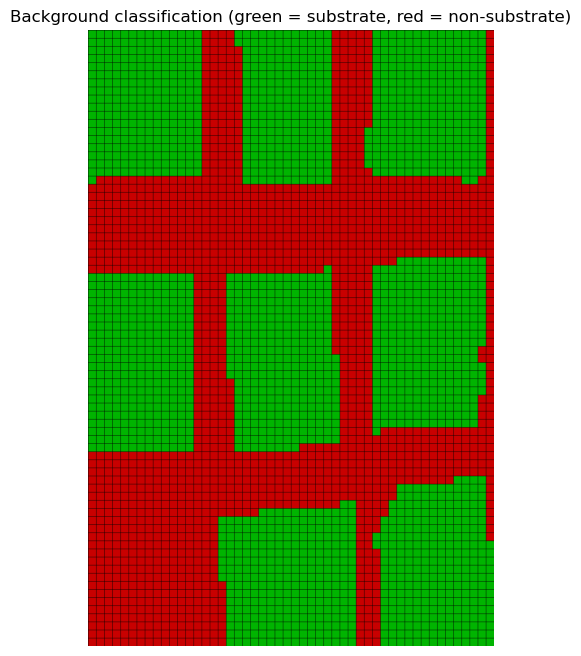

In [9]:
ws.classify_backgrounds()

bg_map = ws.make_background_map()
plt.figure(figsize=(12, 8))
plt.imshow(cv2.cvtColor(bg_map, cv2.COLOR_BGR2RGB))
plt.title("Background classification (green = substrate, red = non-substrate)")
plt.axis("off")
plt.show()

## 3b. Vignetting correction

Compute a flat-field background from **substrate-only** tiles (filtered via the background classifier above), then apply vignetting correction to all tiles.

Computing vignetting model from 3800 images (substrate-only filtering)...
Vignetting model: using 200 substrate images (checked 348/3800, filter_substrate=True)


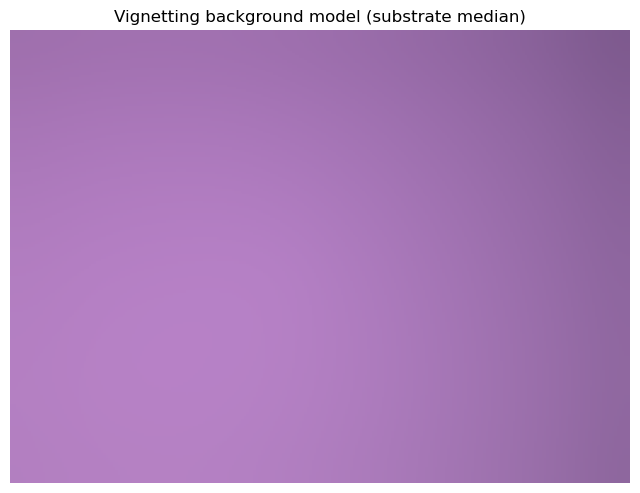

In [10]:
from Flinder import FlinderDetector

all_images = [t["image"] for t in ws.tiles if t.get("image") is not None]
print(f"Computing vignetting model from {len(all_images)} images (substrate-only filtering)...")

background = FlinderDetector.compute_background_from_images(
    all_images,
    n_sample=200,
    filter_substrate=True,
    smooth_sigma=10.0,  # suppress high-frequency texture in flat-field map
)

# Save the model next to the cache
import os
os.makedirs("output", exist_ok=True)
np.save("output/vignetting_bg.npy", background)

# Preview the illumination profile
plt.figure(figsize=(8, 6))
plt.imshow(cv2.cvtColor(np.clip(background, 0, 255).astype(np.uint8), cv2.COLOR_BGR2RGB))
plt.title("Vignetting background model (substrate median)")
plt.axis("off")
plt.show()

  Corrected 500/3800 tiles
  Corrected 1000/3800 tiles
  Corrected 1500/3800 tiles
  Corrected 2000/3800 tiles
  Corrected 2500/3800 tiles
  Corrected 3000/3800 tiles
  Corrected 3500/3800 tiles
  Corrected 3800/3800 tiles


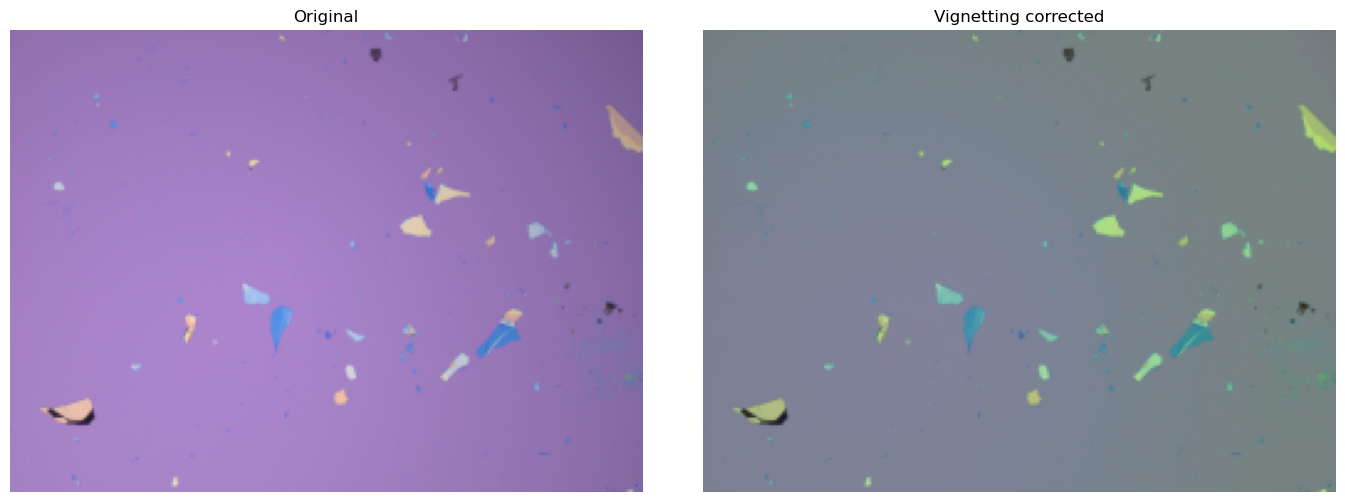

In [11]:
# Store vignetting-corrected images alongside originals (originals untouched).
# per_tile_recenter=False avoids per-tile histogram shifting that creates
# visible seams when tiles are stitched together.
detector = FlinderDetector()
detector.set_background(background)

for i, t in enumerate(ws.tiles):
    if t.get("image") is not None:
        t["image_corrected"] = detector.preprocess_image(
            t["image"],
            per_tile_recenter=False,
            gain_clip=(0.75, 1.35),  # avoid amplifying tiny defects/noise
        )
    if (i + 1) % 500 == 0 or i == len(ws.tiles) - 1:
        print(f"  Corrected {i + 1}/{len(ws.tiles)} tiles")

# Before / after comparison
idx = next(i for i, t in enumerate(ws.tiles) if t.get("image") is not None)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.imshow(cv2.cvtColor(ws.tiles[idx]["image"], cv2.COLOR_BGR2RGB))
ax1.set_title("Original"); ax1.axis("off")
ax2.imshow(cv2.cvtColor(ws.tiles[idx]["image_corrected"], cv2.COLOR_BGR2RGB))
ax2.set_title("Vignetting corrected"); ax2.axis("off")
plt.tight_layout()
plt.show()

## 4. Segment chips via flood-fill

Segmented 8 chip(s): chip 0: 253 tiles, chip 1: 211 tiles, chip 2: 259 tiles, chip 3: 286 tiles, chip 4: 285 tiles, chip 5: 286 tiles, chip 6: 273 tiles, chip 7: 278 tiles


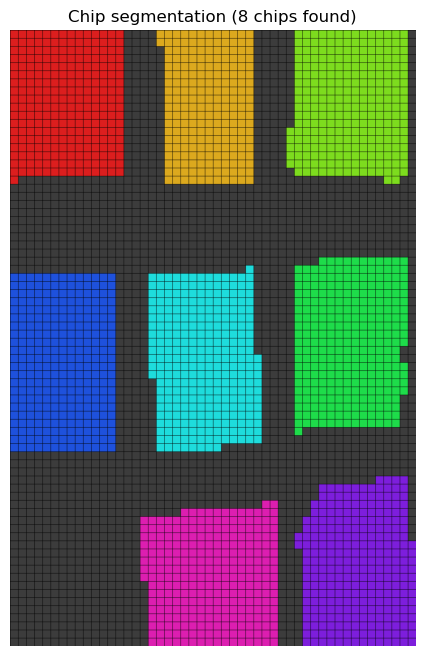

In [12]:
chips = ws.segment_chips()

chip_map = ws.make_chip_map()
plt.figure(figsize=(12, 8))
plt.imshow(cv2.cvtColor(chip_map, cv2.COLOR_BGR2RGB))
plt.title(f"Chip segmentation ({len(chips)} chips found)")
plt.axis("off")
plt.show()

## 4b. Solve tile positions

Estimate per-tile pixel coordinates from pairwise image matching (phase correlation) instead of assuming a rigid lattice. This corrects serpentine backlash and other per-row drift automatically.

Placement solver: 3600 matched edges, 253 rejected (conf < 0.3), 3853 tested
  Solved 3732 tile positions (residual=0.00px per edge)

Diagnostics: {'matched': 3600, 'rejected': 253, 'residual': 0.0, 'n_tiles_solved': 3732}


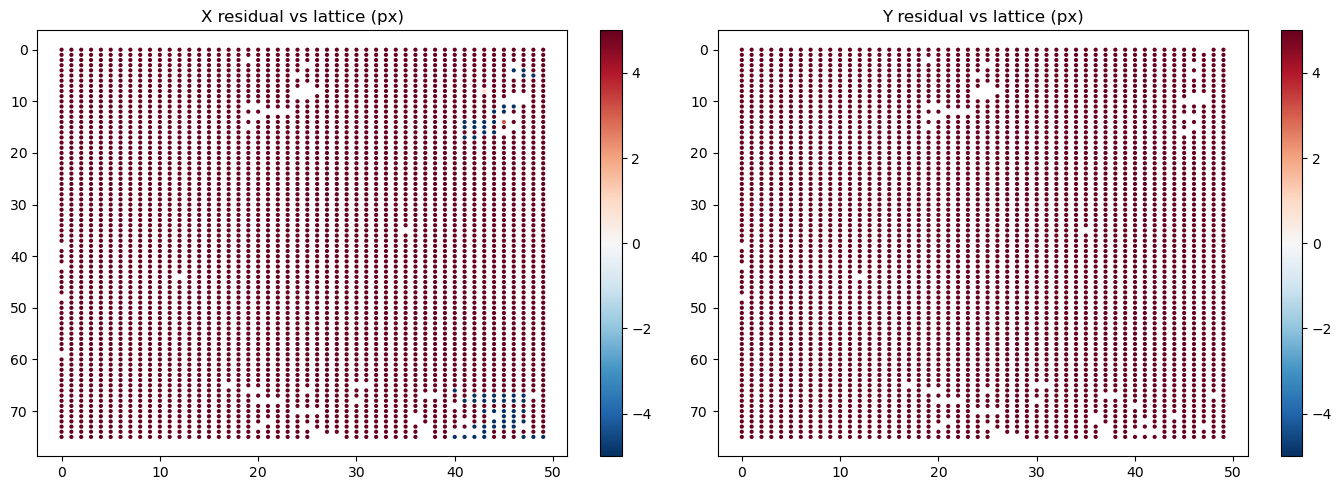

X residual: mean=1834.02, std=974.96, max=4559.51
Y residual: mean=3309.38, std=853.25, max=6301.84


In [13]:
importlib.reload(sys.modules["wafer_stitcher"])
from wafer_stitcher import WaferStitcher

diag = ws.solve_tile_positions(min_confidence=0.3)
print(f"\nDiagnostics: {diag}")

# Show per-tile solved offsets vs lattice expectation
if ws.tile_positions:
    solved_tiles = [t for t in ws.tiles if "px_x" in t and t.get("image") is not None]
    if solved_tiles:
        rows = np.array([t["row"] for t in solved_tiles])
        cols = np.array([t["col"] for t in solved_tiles])
        px_x = np.array([t["px_x"] for t in solved_tiles])
        px_y = np.array([t["px_y"] for t in solved_tiles])

        # Expected lattice positions from median step
        unique_rows = np.sort(np.unique(rows))
        unique_cols = np.sort(np.unique(cols))
        if len(unique_cols) > 1:
            med_step_x = np.median(np.diff(np.sort(px_x[rows == rows[0]])))
        else:
            med_step_x = ws.tile_w
        if len(unique_rows) > 1:
            med_step_y = np.median(np.diff(np.sort(px_y[cols == cols[0]])))
        else:
            med_step_y = ws.tile_h

        lattice_x = cols * med_step_x
        lattice_y = rows * med_step_y
        err_x = px_x - lattice_x
        err_y = px_y - lattice_y

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
        sc1 = ax1.scatter(cols, rows, c=err_x, cmap="RdBu_r", s=4, vmin=-5, vmax=5)
        ax1.set_title("X residual vs lattice (px)")
        ax1.invert_yaxis()
        plt.colorbar(sc1, ax=ax1)
        sc2 = ax2.scatter(cols, rows, c=err_y, cmap="RdBu_r", s=4, vmin=-5, vmax=5)
        ax2.set_title("Y residual vs lattice (px)")
        ax2.invert_yaxis()
        plt.colorbar(sc2, ax=ax2)
        plt.tight_layout()
        plt.show()

        print(f"X residual: mean={err_x.mean():.2f}, std={err_x.std():.2f}, "
              f"max={np.abs(err_x).max():.2f}")
        print(f"Y residual: mean={err_y.mean():.2f}, std={err_y.std():.2f}, "
              f"max={np.abs(err_y).max():.2f}")

## 5. Full stitched overview

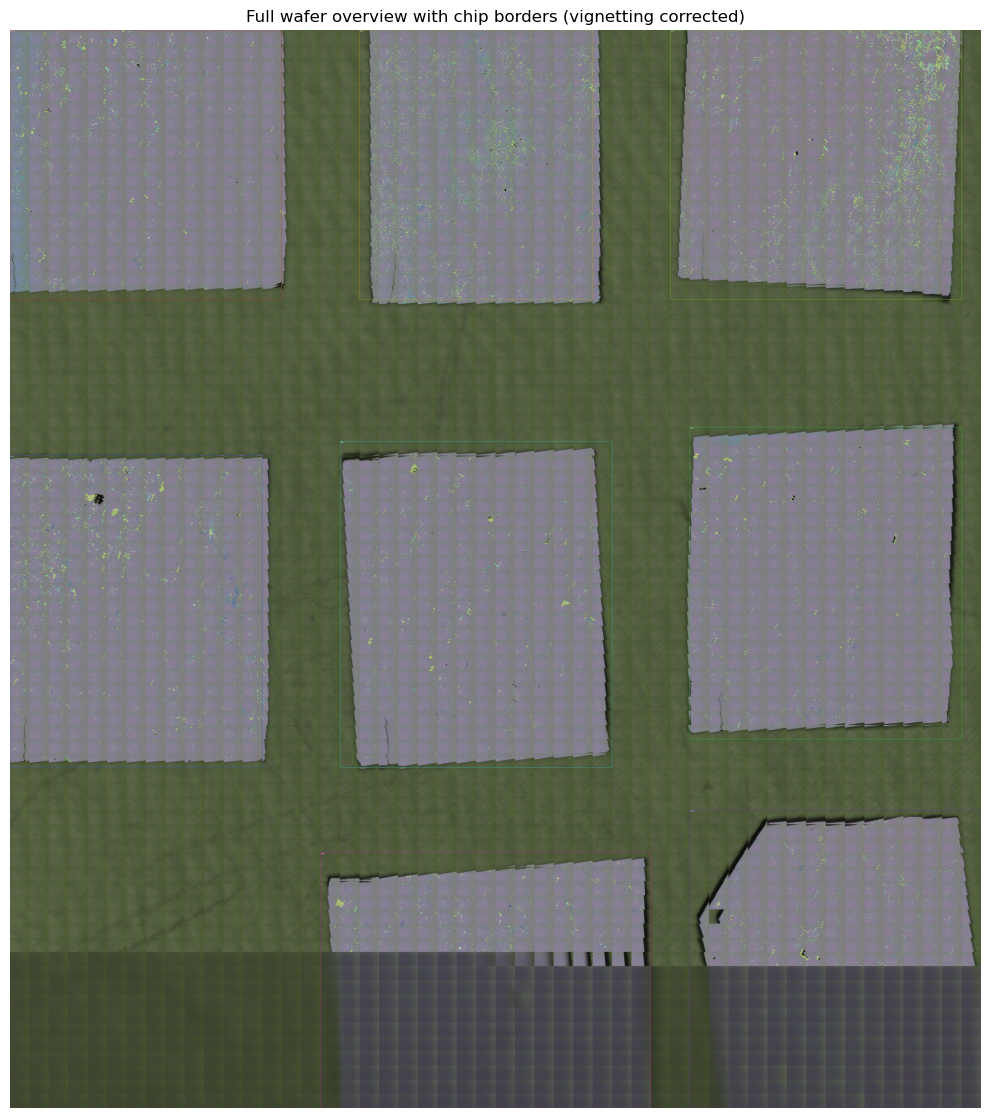

In [14]:
overview = ws.make_overview_with_chip_borders(
    scale=STITCH_SCALE,
    image_key="image_corrected",
    fallback_to_raw=False,
)
plt.figure(figsize=(20, 14))
plt.imshow(cv2.cvtColor(overview, cv2.COLOR_BGR2RGB))
plt.title("Full wafer overview with chip borders (vignetting corrected)")
plt.axis("off")
plt.show()

## 5b. Blended stitch (with overlap detection)

Auto-detects the pixel overlap between adjacent tiles via template matching, then blends the shared regions with linear feathering for seamless seams.

  horizontal overlap: 172px / 256px (67.2%)
  vertical overlap: 122px / 187px (65.2%)
  Iteration 100/3800 (placed 100)
  Iteration 200/3800 (placed 200)
  Iteration 300/3800 (placed 300)
  Iteration 400/3800 (placed 400)
  Iteration 500/3800 (placed 500)
  Iteration 600/3800 (placed 600)
  Iteration 700/3800 (placed 700)
  Iteration 800/3800 (placed 800)
  Iteration 900/3800 (placed 900)
  Iteration 1000/3800 (placed 1000)
  Iteration 1100/3800 (placed 1100)
  Iteration 1200/3800 (placed 1200)
  Iteration 1300/3800 (placed 1300)
  Iteration 1400/3800 (placed 1400)
  Iteration 1500/3800 (placed 1500)
  Iteration 1600/3800 (placed 1600)
  Iteration 1700/3800 (placed 1700)
  Iteration 1800/3800 (placed 1800)
  Iteration 1900/3800 (placed 1900)
  Iteration 2000/3800 (placed 2000)
  Iteration 2100/3800 (placed 2100)
  Iteration 2200/3800 (placed 2200)
  Iteration 2300/3800 (placed 2300)
  Iteration 2400/3800 (placed 2400)
  Iteration 2500/3800 (placed 2500)
  Iteration 2600/3800 (placed 26

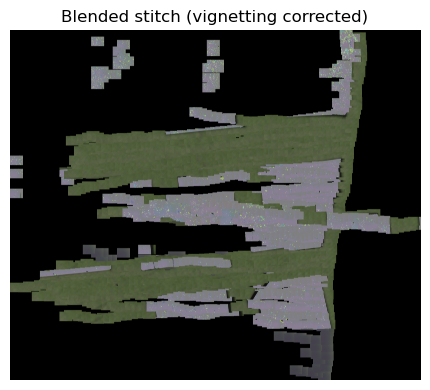

In [15]:
blended = ws.stitch_blended(
    feather=15,
    scale=STITCH_SCALE,
    image_key="image_corrected",
    fallback_to_raw=False,
    placement_mode="solved",
)

plt.figure(figsize=(20, 4))
plt.imshow(cv2.cvtColor(blended, cv2.COLOR_BGR2RGB))
plt.title("Blended stitch (vignetting corrected)")
plt.axis("off")
plt.tight_layout()
plt.show()

## 6. Per-chip stitched images

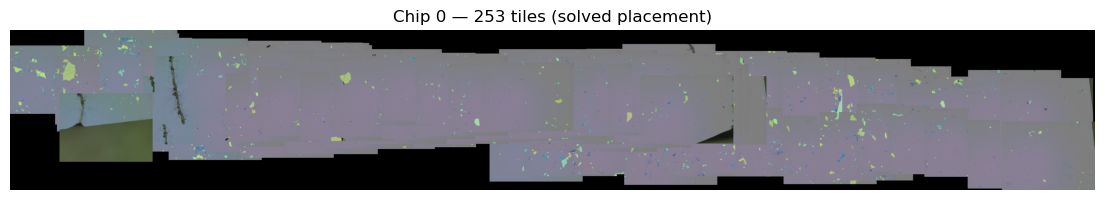

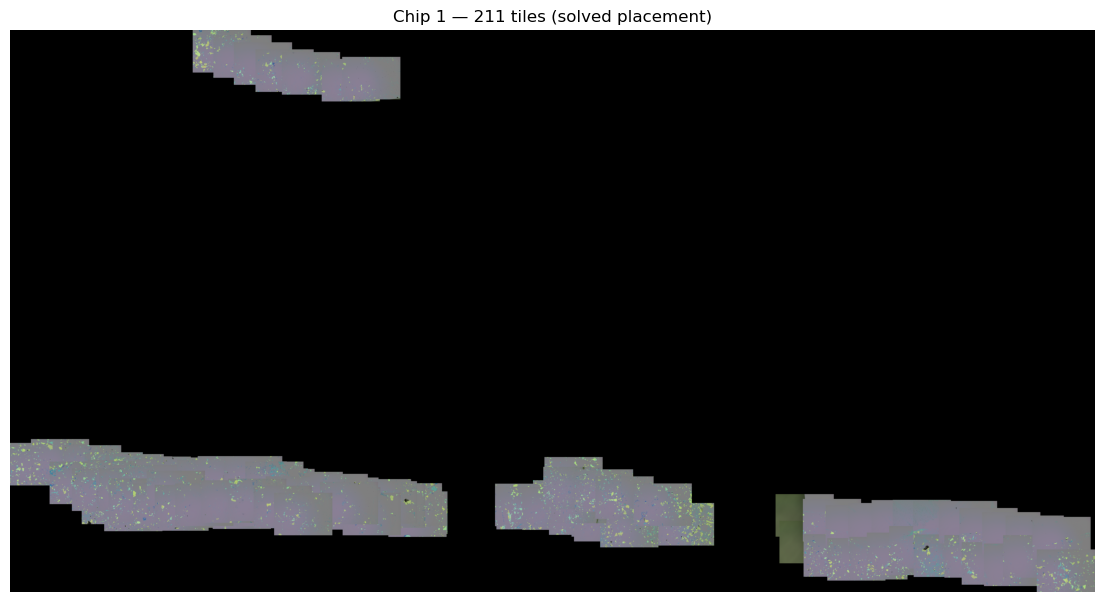

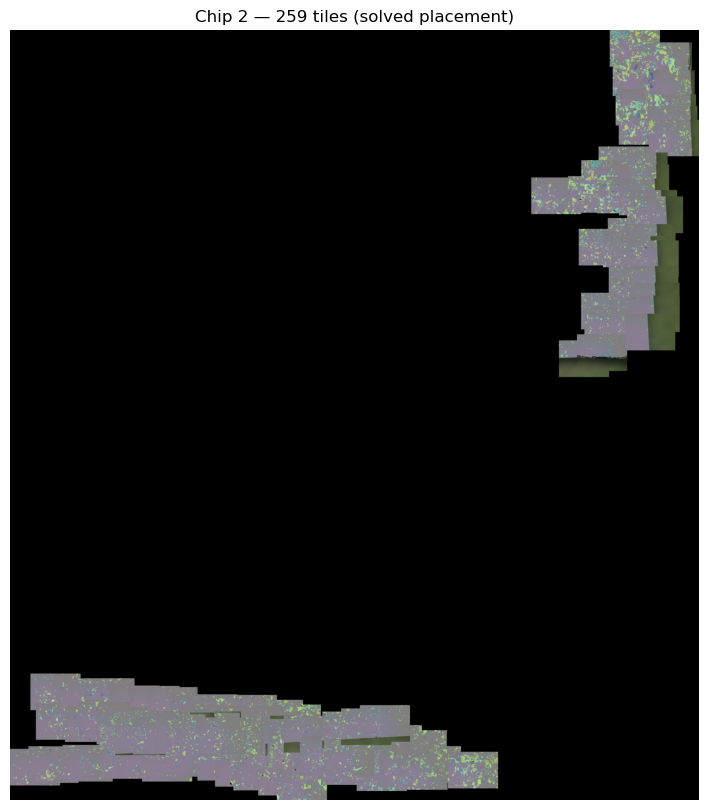

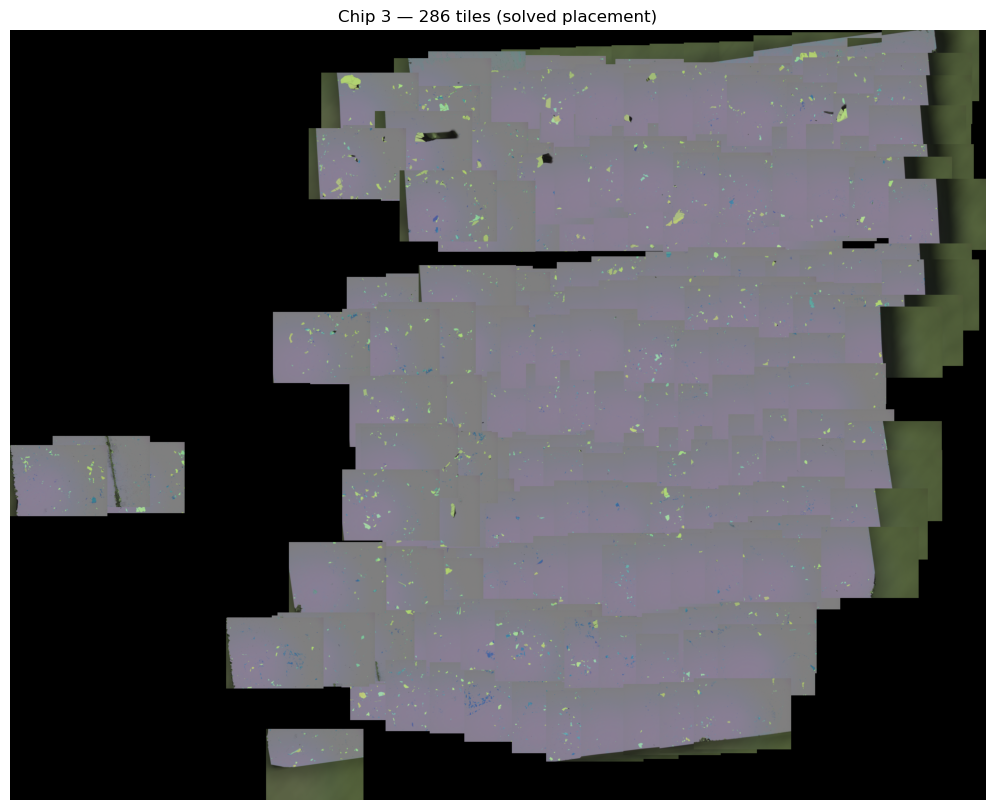

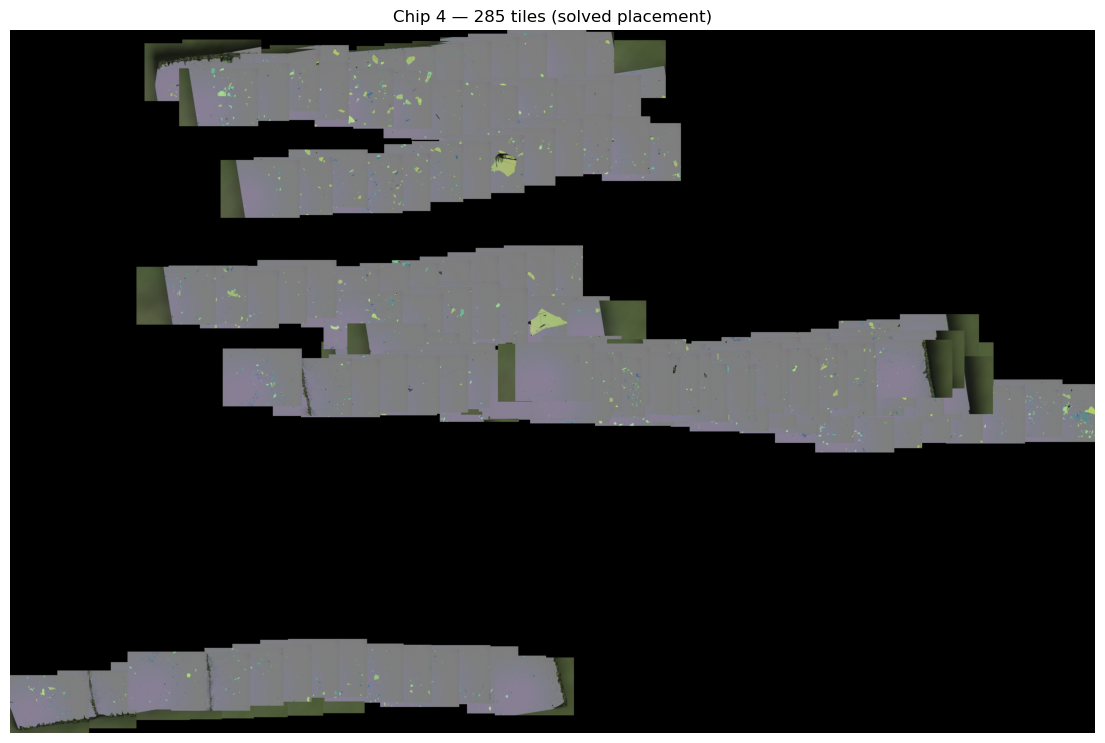

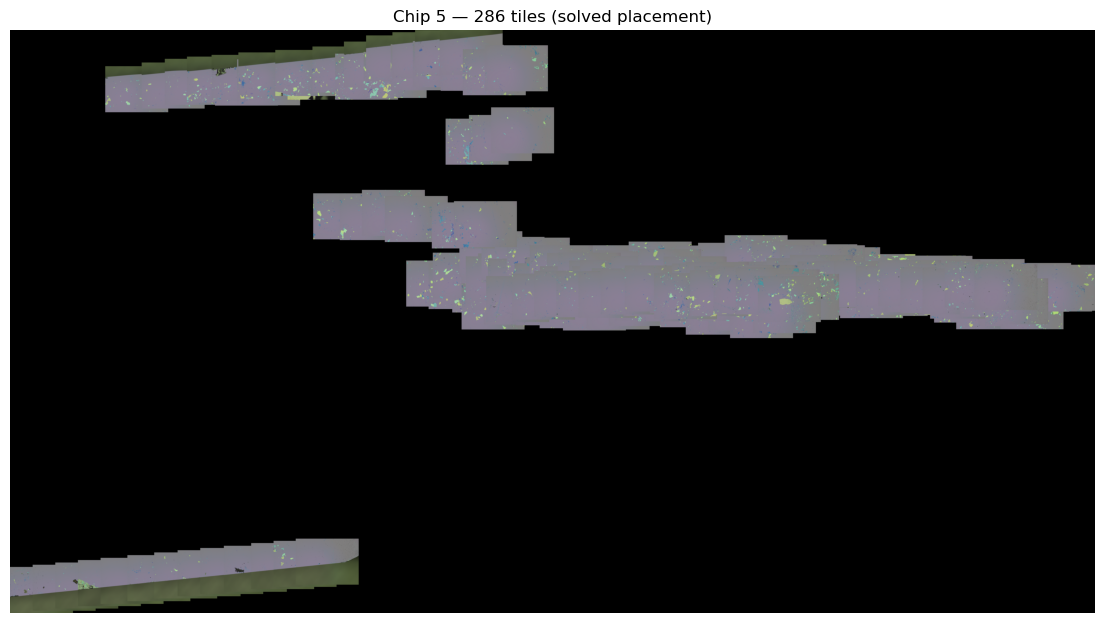

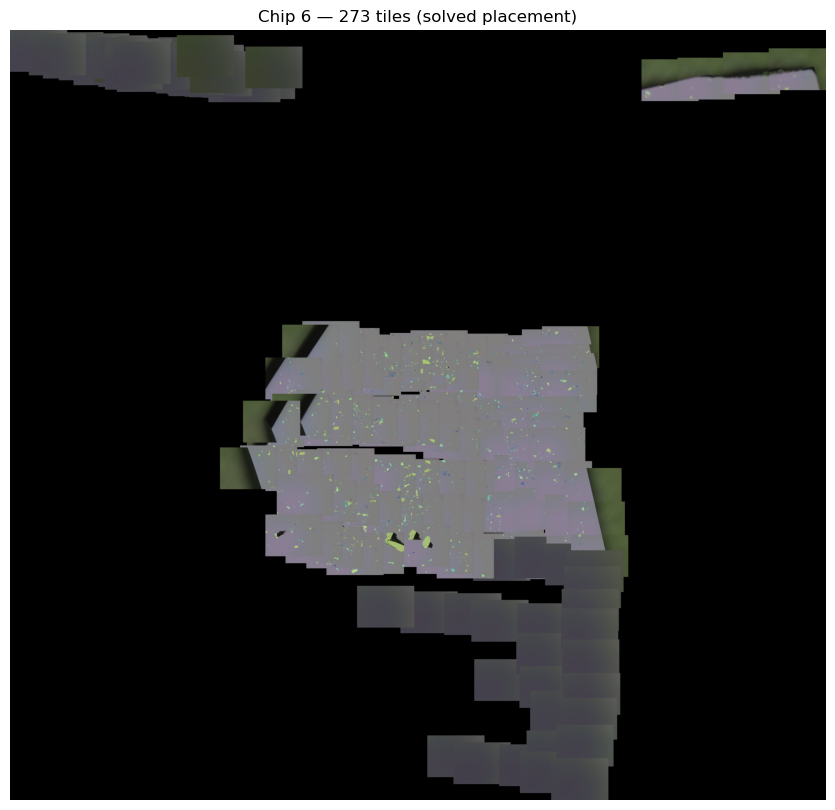

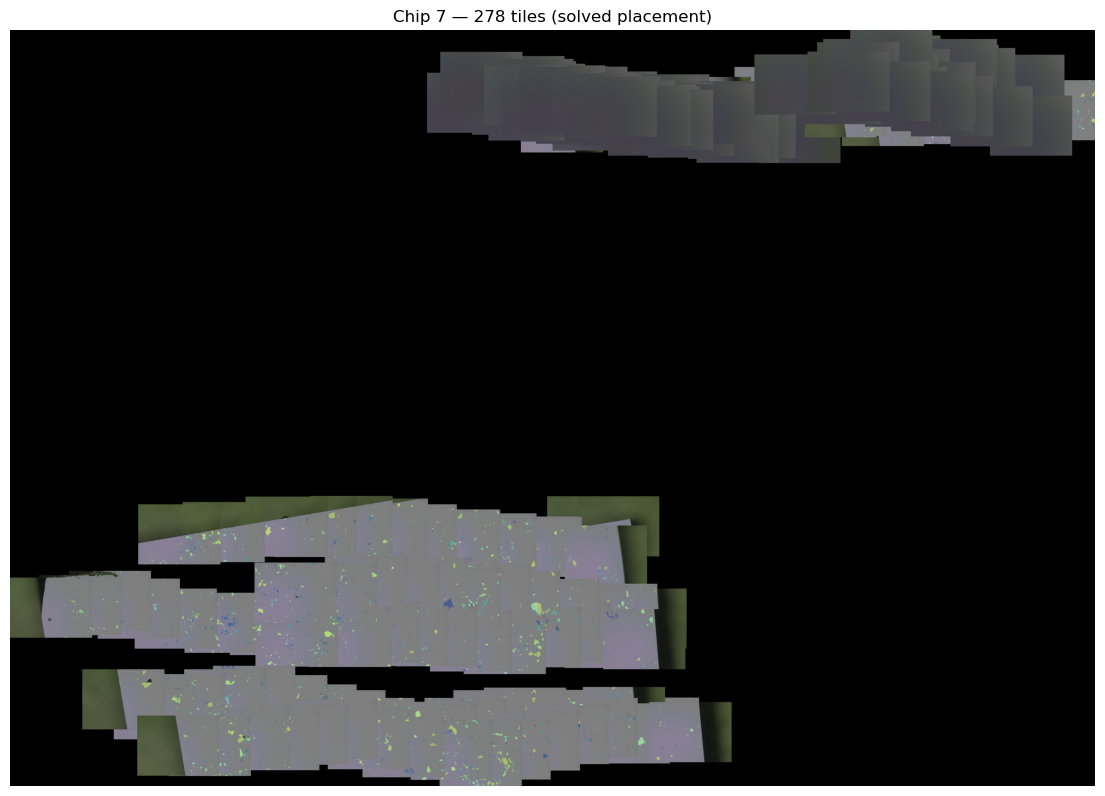

In [16]:
for chip_id in sorted(chips.keys()):
    chip_img = ws.stitch_chip(
        chip_id,
        scale=STITCH_SCALE,
        image_key="image_corrected",
        fallback_to_raw=False,
        placement_mode="solved",
    )
    n_tiles = len(chips[chip_id])

    plt.figure(figsize=(14, 10))
    plt.imshow(cv2.cvtColor(chip_img, cv2.COLOR_BGR2RGB))
    plt.title(f"Chip {chip_id} — {n_tiles} tiles (solved placement)")
    plt.axis("off")
    plt.show()

## 7. Save outputs (optional)

In [16]:
output_dir = os.path.join("output", DATASET_NAME)
os.makedirs(output_dir, exist_ok=True)

cv2.imwrite(os.path.join(output_dir, "overview.png"), overview)
cv2.imwrite(os.path.join(output_dir, "background_map.png"), bg_map)
cv2.imwrite(os.path.join(output_dir, "chip_map.png"), chip_map)

for chip_id in sorted(chips.keys()):
    chip_img = ws.stitch_chip(
        chip_id,
        scale=STITCH_SCALE,
        image_key="image_corrected",
        fallback_to_raw=False,
        placement_mode="solved",
    )
    cv2.imwrite(os.path.join(output_dir, f"chip_{chip_id}.png"), chip_img)

print(f"Saved outputs to {output_dir}/")

Saved outputs to output/collection_2026-03-01_20-02-22/
